In [1]:
import rush_hour_rl as rl
import rush_hour_lib as lib
import random
import torch
from sklearn.model_selection import train_test_split

In [2]:
GAMMA = 0.2  # probability an AND-OR OrNode abandons its subgoal for a random legal move (see rush_hour_and_or.solve)

In [3]:
SPLIT_SEED = 3  # shuffles which puzzles land in train vs. test - see the split cell below
TRAIN_SIZE = 0.9  # fraction of the cluster pool used for training; the rest is held out as test

In [4]:
# lib.sample_puzzles("data/rush_nw_training.txt", num=100)

In [5]:
puzzles = lib.read_puzzles("data/rush_nw_cluster.txt")

## Apprentice/teacher (ExIt) model, plain behavior cloning

Trains via `train_policy_bc` (supervised imitation of AND-OR: one batch of solve attempts, one training pass) rather than DQN. `PolicyAgent` is policy-only (no value head) and its greedy rollout uses `policy_avoiding_cycles`: it ranks legal actions by logit and falls back to the next-best one whenever the top choice would revisit an already-seen state, so a single bad decision can't strand the rollout in a 2-cycle until `max_steps` runs out. `train_policy` also applies an exponential moving average (`ema_decay`) over the trained weights across epochs, smoothing the epoch-to-epoch instability visible in `steps_history` below.</cell id="65441130">


In [6]:
# rush_nw_cluster.txt is a small, hand-picked pool spanning multiple
# distances rather than a single-DIST bucket, so puzzles are pooled across
# every distance present in the file before splitting. train_test_split
# shuffles the pool under SPLIT_SEED and splits it by TRAIN_SIZE - a
# proportion rather than a fixed held-out count, since the pool size varies
# as the cluster file is regenerated. SPLIT_SEED is kept separate from the
# training seed below so reshuffling the split doesn't also change AND-OR's
# search / the network's initialization, and vice versa.
all_puzzles = [puzzle for dist in sorted(puzzles) for puzzle in puzzles[dist]]
all_distances = [dist for dist in sorted(puzzles) for puzzle in puzzles[dist]]

train_puzzles, test_puzzles, train_distances, test_distances = train_test_split(
    all_puzzles, all_distances, train_size=TRAIN_SIZE, random_state=SPLIT_SEED
)

In [7]:
# Seeded for reproducibility - torch.manual_seed matters as much as
# random.seed here: random.seed alone only controls AND-OR's own search,
# not PyTorch's weight init / batch shuffling, a separate source of
# run-to-run variance in whether the policy head solves independently.
random.seed(3)
torch.manual_seed(0)

trainer = rl.PuzzleTrainer(train_puzzles, test_puzzles, (6, 6),
                            train_distances=train_distances, test_distances=test_distances)
n_examples, policy_loss, train_results, test_results, and_or_stats = trainer.train(
    n_traces=15, epochs=10, max_steps=200,
    max_examples=20000, eval_every=10,
    and_or_eval_trials=30, n_rounds=3, gamma=GAMMA
)
print(f"examples={n_examples}  policy_loss={policy_loss:.3f}")
print(f"train_results={train_results}")
print(f"test_results={test_results}")
print(f"and_or_stats={and_or_stats}")

training epochs (round 3/3): 100%|██████████| 10/10 [00:01<00:00,  8.71it/s]


examples=2581  policy_loss=0.075
train_results=[(True, 21), (True, 20), (True, 12), (True, 33), (True, 22), (True, 40), (True, 21), (True, 17), (True, 34), (True, 57), (True, 19), (True, 14), (True, 14), (True, 42)]
test_results=[(True, 13), (True, 58)]
and_or_stats=[(1.0, 20.733333333333334), (1.0, 21.8), (1.0, 18.166666666666668), (1.0, 19.966666666666665), (1.0, 29.433333333333334), (1.0, 27.366666666666667), (1.0, 16.8), (1.0, 31.766666666666666), (1.0, 24.966666666666665), (1.0, 24.433333333333334), (1.0, 16.3), (1.0, 19.266666666666666), (1.0, 21.7), (1.0, 22.833333333333332)]


## Self-play isolation: is ExIt (rounds 2+) actually helping on this pool?

The run above uses `n_rounds=3`: round 1 is plain behavior cloning from unbiased AND-OR search, rounds 2-3 are heuristic-guided self-play (Expert Iteration). On this bigger, distance-9-to-14 pool, train/test performance has been observed to get *worse* over the course of training rather than better - which could mean the self-play rounds are net-negative here (a not-yet-competent policy biasing its own teacher's search into worse demonstrations, a known ExIt failure mode absent a curriculum), rather than a fundamental problem with behavior cloning itself.

This cell reruns the identical setup with `n_rounds=1` (round 1 only - no self-play) as a baseline, and compares its final train/test performance directly against the `n_rounds=3` run above, using the same distance-normalized scoring as the round-level regression guard (see `_train_score` in rush_hour_rl.py). If the `n_rounds=1` baseline matches or beats the `n_rounds=3` result, that's strong evidence the self-play rounds are actively hurting rather than helping right now.

In [8]:
# Same seeds/hyperparameters as the n_rounds=3 run above, differing only in
# n_rounds - isolates the self-play rounds' own effect rather than any
# confound from a different seed or trace/epoch budget.
random.seed(3)
torch.manual_seed(0)

baseline_trainer = rl.PuzzleTrainer(train_puzzles, test_puzzles, (6, 6),
                                     train_distances=train_distances, test_distances=test_distances)
bl_n_examples, bl_policy_loss, bl_train_results, bl_test_results, bl_and_or_stats = baseline_trainer.train(
    n_traces=15, epochs=10, max_steps=200,
    max_examples=20000, eval_every=10,
    and_or_eval_trials=30, n_rounds=1, gamma=GAMMA
)


def summarize(results, distances):
    ratios = [s / d for (solved, s), d in zip(results, distances) if solved]
    solved_count = len(ratios)
    if not ratios:
        return f"{solved_count}/{len(results)} solved"
    return f"{solved_count}/{len(results)} solved, mean steps/optimal={sum(ratios) / len(ratios):.2f}"


print("n_rounds=3 (ExIt, cell above):")
print(f"  train: {summarize(train_results, train_distances)}")
print(f"  test:  {summarize(test_results, test_distances)}")
print("n_rounds=1 (plain BC baseline, this cell):")
print(f"  train: {summarize(bl_train_results, train_distances)}")
print(f"  test:  {summarize(bl_test_results, test_distances)}")

training epochs (round 1/1): 100%|██████████| 10/10 [00:07<00:00,  1.33it/s]


n_rounds=3 (ExIt, cell above):
  train: 14/14 solved, mean steps/optimal=2.18
  test:  2/2 solved, mean steps/optimal=2.77
n_rounds=1 (plain BC baseline, this cell):
  train: 14/14 solved, mean steps/optimal=2.46
  test:  2/2 solved, mean steps/optimal=4.33


In [9]:
import os
os.makedirs("models", exist_ok=True)
trainer.agent.save("models/policy_agent.pt")

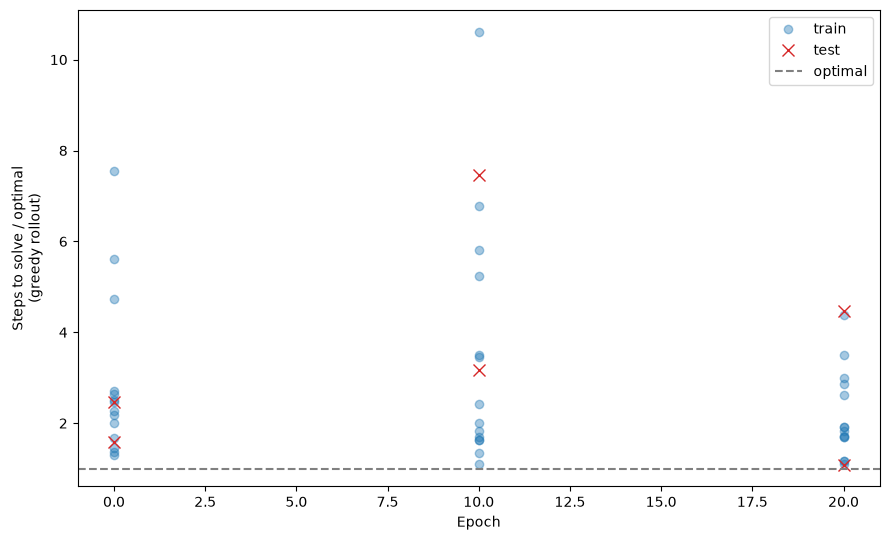

In [10]:
import matplotlib.pyplot as plt

epochs = [e for e, _, _ in trainer.history]

plt.figure(figsize=(9, 5.5))
# linestyle="None": these are isolated solved/unsolved checkpoints, not a
# continuous quantity - a connecting line would draw a straight (and
# misleading) segment across epochs that didn't solve (nan) in between.
# Steps are normalized by each puzzle's own optimal length (train_distances/
# test_distances), same as the fine-tuning plot below, since the pool spans
# multiple distances rather than one shared DIST.
for i in range(len(train_puzzles)):
    steps = [train_i[i][1] / train_distances[i] for _, train_i, _ in trainer.history]
    plt.plot(epochs, steps, marker="o", linestyle="None", color="tab:blue", alpha=0.4,
              label="train" if i == 0 else None)
for i in range(len(test_puzzles)):
    steps = [test_i[i][1] / test_distances[i] for _, _, test_i in trainer.history]
    plt.plot(epochs, steps, marker="x", linestyle="None", color="tab:red", markersize=8,
              label="test" if i == 0 else None)
plt.axhline(1.0, color="gray", linestyle="--", label="optimal")
plt.xlabel("Epoch"); plt.ylabel("Steps to solve / optimal\n(greedy rollout)")
plt.legend()
plt.tight_layout()
plt.savefig("visualization/apprentice_bc.png")
plt.show()

## Fine-tuning convergence: pretrained vs. scratch

The plot above scores the pretrained agent zero-shot on each test puzzle - no gradients from the test puzzles themselves. Here instead each test puzzle gets fine-tuned on directly (via `finetune_curve`, which points a `PuzzleTrainer` at a single puzzle and runs the same heuristic-guided ExIt loop), starting once from the saved pretrained checkpoint and once from a fresh, randomly-initialized agent - to see whether the shared cross-puzzle representation lets it converge to an optimal-length solution in fewer fine-tuning epochs than starting from scratch. Since the pool can span multiple distances rather than one fixed `DIST`, each test puzzle's steps-to-solve is normalized by its own optimal length (`test_distances`, its BFS distance) before averaging, so `average_curves` still produces one comparable curve (1.0 = optimal) instead of assuming every puzzle in the set shares the same optimal length.

In [11]:
FT_KWARGS = dict(n_traces=10, epochs=5, n_rounds=6, eval_every=1, gamma=GAMMA)  # 30 fine-tuning epochs/puzzle

# The fine-tune loop below trains two full agents (pretrained + scratch) per
# puzzle, so its cost scales directly with how many puzzles it's given -
# capped to a handful here rather than run over every held-out test puzzle,
# which is unnecessary for a comparison plot. train_puzzles/test_puzzles
# themselves (used by the trainer.train() cell above) are left untouched.
FT_TEST_SIZE = 5
ft_test_puzzles = test_puzzles[:FT_TEST_SIZE]
ft_test_distances = test_distances[:FT_TEST_SIZE]

pretrained_curves, scratch_curves = [], []
for i, puzzle in enumerate(ft_test_puzzles):
    random.seed(100 + i); torch.manual_seed(100 + i)
    pretrained_curves.append(rl.finetune_curve(rl.PolicyAgent.load("models/policy_agent.pt"), puzzle, (6, 6), **FT_KWARGS))

    random.seed(100 + i); torch.manual_seed(100 + i)
    scratch_curves.append(rl.finetune_curve(rl.PolicyAgent((6, 6)), puzzle, (6, 6), **FT_KWARGS))

training epochs (round 1/6): 100%|██████████| 5/5 [00:00<00:00, 15.60it/s]


training epochs (round 5/6): 100%|██████████| 5/5 [00:00<00:00, 18.71it/s]


training epochs (round 6/6): 100%|██████████| 5/5 [00:00<00:00, 25.44it/s]


training epochs (round 6/6): 100%|██████████| 5/5 [00:00<00:00,  8.87it/s]


training epochs (round 1/6): 100%|██████████| 5/5 [00:00<00:00,  7.63it/s]


...

training epochs (round 2/6): 100%|██████████| 5/5 [00:00<00:00, 17.54it/s]


training epochs (round 3/6): 100%|██████████| 5/5 [00:00<00:00, 14.66it/s]


training epochs (round 4/6): 100%|██████████| 5/5 [00:00<00:00, 23.96it/s]


training epochs (round 5/6): 100%|██████████| 5/5 [00:00<00:00, 23.47it/s]


training epochs (round 6/6): 100%|██████████| 5/5 [00:00<00:00, 19.22it/s]

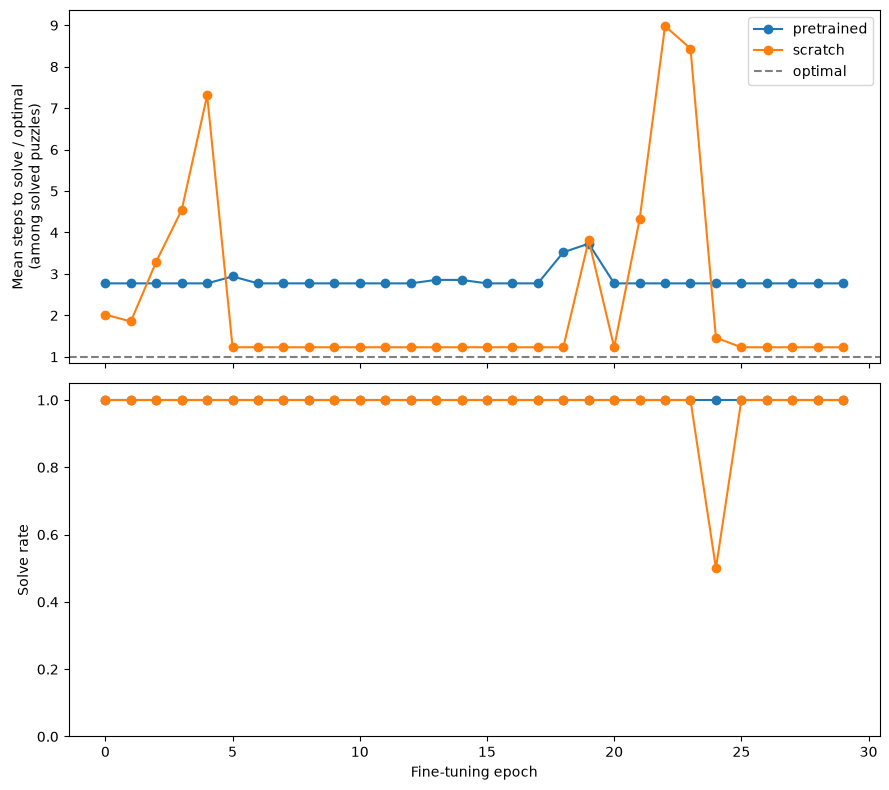

In [12]:
pre_epochs, pre_steps, pre_rate = rl.average_curves(pretrained_curves, optimal=ft_test_distances)
scr_epochs, scr_steps, scr_rate = rl.average_curves(scratch_curves, optimal=ft_test_distances)

fig, (ax_steps, ax_rate) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

ax_steps.plot(pre_epochs, pre_steps, marker="o", color="tab:blue", label="pretrained")
ax_steps.plot(scr_epochs, scr_steps, marker="o", color="tab:orange", label="scratch")
ax_steps.axhline(1.0, color="gray", linestyle="--", label="optimal")
ax_steps.set_ylabel("Mean steps to solve / optimal\n(among solved puzzles)")
ax_steps.legend()

ax_rate.plot(pre_epochs, pre_rate, marker="o", color="tab:blue", label="pretrained")
ax_rate.plot(scr_epochs, scr_rate, marker="o", color="tab:orange", label="scratch")
ax_rate.set_ylim(0, 1.05)
ax_rate.set_xlabel("Fine-tuning epoch")
ax_rate.set_ylabel("Solve rate")

plt.tight_layout()
plt.savefig("visualization/finetune_convergence.png")
plt.show()